In [1]:
import dask
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
import matplotlib.axes as maxes
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from windrose import WindroseAxes
from io import BytesIO
import warnings
from datetime import datetime, timedelta
import xarray as xr
import glob
warnings.filterwarnings('ignore')

In [2]:
# Define datasets to load: (name, glob_pattern, variable, height_level, y_offset, color)
datasets_config = [
    ('Nant Winds', '/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*', 'wd', 100, 1.0, 'blue'),
    ('Nant Rain', '/qfs/people/gold396/ORACLE/wfip3/nant.ld.z01.b1/*', 'rain_intensity', None, 0.5, 'blue'),
    ('Asit Winds', '/qfs/people/gold396/ORACLE/wfip3/asit.lidar.z01.a0/*', 'horizontal_wind_direction', 97, 0.0, 'orange'),
    ('Asit Rain 1', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z01.b1/*', 'rain_intensity', None, -0.25, 'orange'),
    ('Asit Rain 2', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z02.b1/*', 'rain_intensity', None, -0.75, 'orange'),
    ('Barg Winds', '/qfs/people/gold396/ORACLE/wfip3/barg.lidar.z02.a0/*', 'wind_direction', 100, -1.0, 'green'),
    ('Barg Rain 1', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z01.b1/*', 'rain_intensity', None, -1.25, 'green'),
    ('Barg Rain 2', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z02.b1/*', 'rain_intensity', None, -1.75, 'green'),
]

# Load all datasets efficiently
datasets = {}
for name, pattern, _, _, _, _ in datasets_config:
    try:
        ds = xr.open_mfdataset(sorted(glob.glob(pattern)), combine='by_coords')
        datasets[name] = ds
        print(f"✓ Loaded {name}: {len(ds.time)} time steps")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")


✓ Loaded Nant Winds: 24148 time steps
✓ Loaded Nant Rain: 1281227 time steps
✓ Loaded Asit Winds: 1711978 time steps
✓ Loaded Asit Rain 1: 1374314 time steps
✓ Loaded Asit Rain 2: 1297933 time steps
✓ Loaded Barg Winds: 15623 time steps
✓ Loaded Barg Rain 1: 748036 time steps
✓ Loaded Barg Rain 2: 434560 time steps


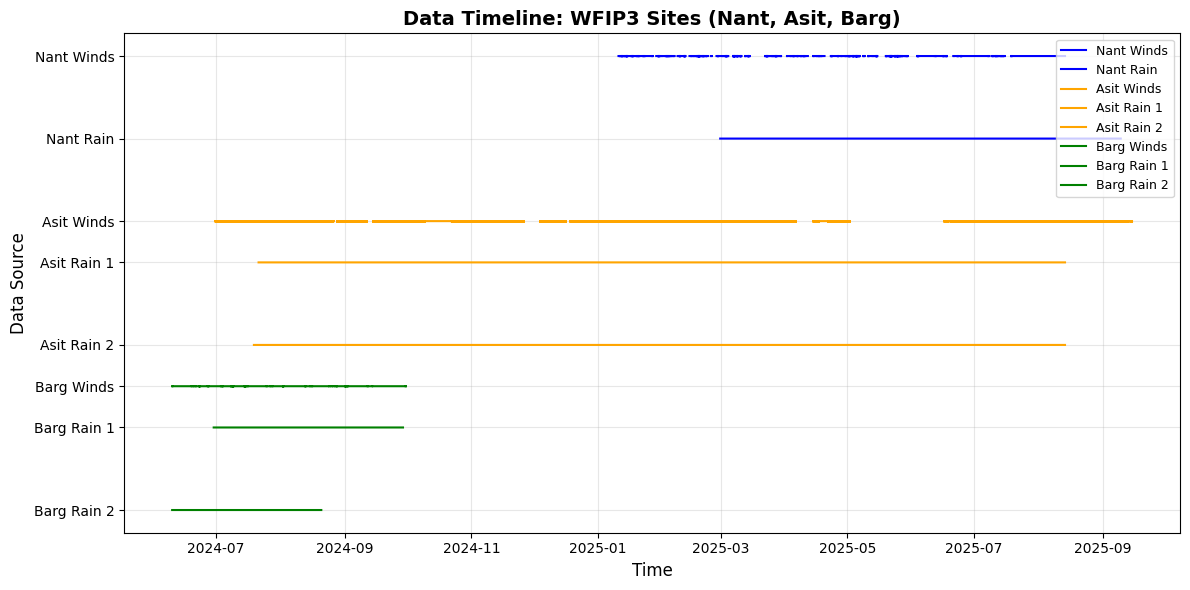

In [9]:
# Efficient refactored plotting using the datasets_config
fig, ax = plt.subplots(figsize=(12, 6))

# Plot all datasets using loop
for label, pattern, var, height, y_offset, color in datasets_config:
    if label not in datasets:
        print(f"Skipping {label}: not loaded")
        continue
    
    ds = datasets[label]
    try:
        if var not in ds.data_vars:
            print(f"  Skipping {var}: not in {label}")
            continue
        
        # Extract variable; select height if specified
        data = ds[var]
        if height is not None and 'height' in data.dims:
            data = data.sel(height=height, method='nearest')
        
        # Plot: y_offset values only mark timeline, time values show when data exists
        valid = np.isfinite(data.values)
        y = np.full(ds.time.size, np.nan, dtype=float)
        y[valid] = y_offset
        ax.plot(ds.time.values, y, label=label, color=color, linewidth=1.5)
        # ax.plot(ds.time, xr.full_like(ds.time, y_offset), label=label, color=color, linewidth=1.5)
    except Exception as e:
        print(f"  Error plotting {label}: {e}")

# Set labels and formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Data Source', fontsize=12)
positions = [row[4] for row in datasets_config]
labels_list = [row[0] for row in datasets_config]
ax.set_yticks(positions, labels_list, fontsize=10)
ax.set_title('Data Timeline: WFIP3 Sites (Nant, Asit, Barg)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

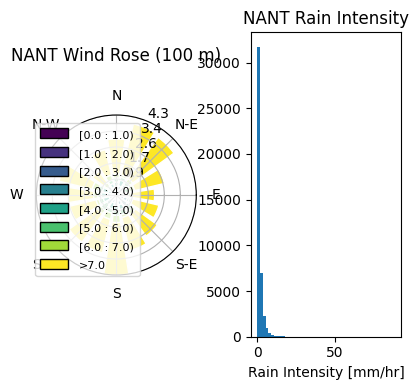

In [ ]:
fig = plt.figure(figsize=(7, 7))

# Windrose subplot (left) — WindroseAxes requires manual rect positioning
ax1 = WindroseAxes(fig, [0.05, 0.1, 0.4, 0.8])
fig.add_axes(ax1)
ws = datasets['Nant Winds']['ws'].sel(height=100).values  # wind speeds
wd = datasets['Nant Winds']['wd'].sel(height=100).values  # wind directions
ax1.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax1.set_legend()
ax1.set_title('NANT Wind Rose (100 m)', pad=20)

# Rain intensity histogram subplot (right)
ax2 = fig.add_subplot(1, 2, 2)
rain = datasets['Nant Rain']['rain_intensity'].where(datasets['Nant Rain']['rain_intensity'] > 0)
rain.plot.hist(bins=50, ax=ax2)
ax2.set_title('NANT Rain Intensity')

plt.tight_layout()
plt.show()


In [ ]:
WD = datasets['Asit Winds']['horizontal_wind_direction'].sel(height=100, method = 'nearest')

ds1 = datasets["Asit Rain 1"]   # Dataset
ds2 = datasets["Asit Rain 2"]   # Dataset

# Boolean masks (True where condition met)
mask_ns = ((WD > 315) | (WD < 45) | ((WD > 135) & (WD < 225)))
mask_ew = (((WD > 45) & (WD < 135)) | ((WD > 225) & (WD < 315)))

# Make sure they align to the datasets' time coordinate (choose method)
# If WD is coarser than ds1/ds2, this pushes WD mask onto the finer time grid.
mask_ns_1 = mask_ns.reindex(time=ds1.time, method="ffill") # this one
mask_ew_1 = mask_ew.reindex(time=ds1.time, method="ffill")

mask_ns_2 = mask_ns.reindex(time=ds2.time, method="ffill")
mask_ew_2 = mask_ew.reindex(time=ds2.time, method="ffill") # this one

# Combine: take ds1 values where NS, take ds2 where EW; elsewhere NaN
out1 = ds1.where(mask_ns_1)
out2 = ds2.where(mask_ew_2)

# new_ds = xr.where(mask_ns_1, ds1, xr.where(mask_ew_2, ds2, xr.nan))
# # equivalently: new_ds = out1.combine_first(out2)  # but only if masks don't overlap

# new_ds.to_netcdf('/qfs/people/gold396/ORACLE/wfip3/asit_merged_rain.nc')

: 

In [ ]:
out1.to_netcdf('/qfs/people/gold396/ORACLE/wfip3/asit_rain_ns.nc')
out2.to_netcdf('/qfs/people/gold396/ORACLE/wfip3/asit_rain_ew.nc')

In [7]:
new_ds = xr.where(mask_ns_1, ds1, xr.where(mask_ew_1, ds2))
new_ds.to_netcdf('/qfs/people/gold396/ORACLE/wfip3/asit_merged_rain.nc')

TypeError: where() missing 1 required positional argument: 'y'

# Barge

In [24]:
# Define datasets to load: (name, glob_pattern, variable, height_level, y_offset, color)
datasets_config = [
    ('Barg Winds', '/qfs/people/gold396/ORACLE/wfip3/barg.lidar.z02.a0/*', 'wind_direction', 100, -1.0, 'green'),
    ('Barg Rain 1', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z01.b1/*', 'rain_intensity', None, -1.25, 'green'),
    ('Barg Rain 2', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z02.b1/*', 'rain_intensity', None, -1.75, 'green'),
]

# Load all datasets efficiently
datasets = {}
for name, pattern, _, _, _, _ in datasets_config:
    try:
        ds = xr.open_mfdataset(sorted(glob.glob(pattern)), combine='by_coords')
        datasets[name] = ds
        print(f"✓ Loaded {name}: {len(ds.time)} time steps")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")


✓ Loaded Barg Winds: 15623 time steps
✓ Loaded Barg Rain 1: 748036 time steps
✓ Loaded Barg Rain 2: 434560 time steps


In [25]:

# Find days where ALL three datasets have data, then mask to those days only
def get_valid_days(ds, var='rain_intensity'):
    """Return a set of dates (day resolution) where the variable has at least one non-NaN value."""
    data = ds[var] if var in ds else next(iter(ds.data_vars.values()), None)
    if data is None:
        return set()
    # Collapse any non-time dims, check for any valid value per day
    daily_valid = data.resample(time='1D').any(skipna=False) if False else (
        np.isfinite(data.values).any(axis=tuple(range(1, data.ndim)))
        if data.ndim > 1 else np.isfinite(data.values)
    )
    times = ds.time.values
    days = pd.to_datetime(times).normalize()  # truncate to date
    return set(days[daily_valid])

wind_var = 'wind_direction'
wind_days = get_valid_days(datasets['Barg Winds'], wind_var)
rain1_days = get_valid_days(datasets['Barg Rain 1'], 'rain_intensity')
rain2_days = get_valid_days(datasets['Barg Rain 2'], 'rain_intensity')

common_days = wind_days & rain1_days & rain2_days
print(f"Barg Winds valid days:  {len(wind_days)}")
print(f"Barg Rain 1 valid days: {len(rain1_days)}")
print(f"Barg Rain 2 valid days: {len(rain2_days)}")
print(f"Overlapping days:       {len(common_days)}")

# Build a boolean mask for each dataset's time coordinate
def mask_to_common_days(ds, common_days):
    common_days = pd.DatetimeIndex(common_days).normalize()
    time_days = ds["time"].dt.floor("D")
    mask = time_days.isin(common_days)
    ds_filtered = ds.where(mask, drop=True)
    return ds_filtered

datasets['Barg Winds']  = mask_to_common_days(datasets['Barg Winds'],  common_days)
datasets['Barg Rain 1'] = mask_to_common_days(datasets['Barg Rain 1'], common_days)
datasets['Barg Rain 2'] = mask_to_common_days(datasets['Barg Rain 2'], common_days)

print(f"\nAfter masking:")
for name in ['Barg Winds', 'Barg Rain 1', 'Barg Rain 2']:
    print(f"  {name}: {len(datasets[name].time)} time steps")


Barg Winds valid days:  113
Barg Rain 1 valid days: 89
Barg Rain 2 valid days: 52
Overlapping days:       39

After masking:
  Barg Winds: 5321 time steps
  Barg Rain 1: 336905 time steps
  Barg Rain 2: 323259 time steps


In [34]:
day_ds

<xarray.Dataset> Size: 3MB
Dimensions:                      (time: 8640)
Coordinates:
    height                       float64 8B 100.0
  * time                         (time) datetime64[ns] 69kB 2024-06-30 ... 20...
Data variables: (12/41)
    rain_intensity               (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    rain_accumulated             (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4680      (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4677      (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4678      (time) object 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_nws             (time) object 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                           ...
    qc_sensor_voltage            (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_sensor_status             (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_right_sensor_temperature  (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_left_sensor_temperature   (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_kinetic_energy            (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_snow_intensity            (time) float64 69kB dask.array<chunksize=(1,), meta=np.ndarray>

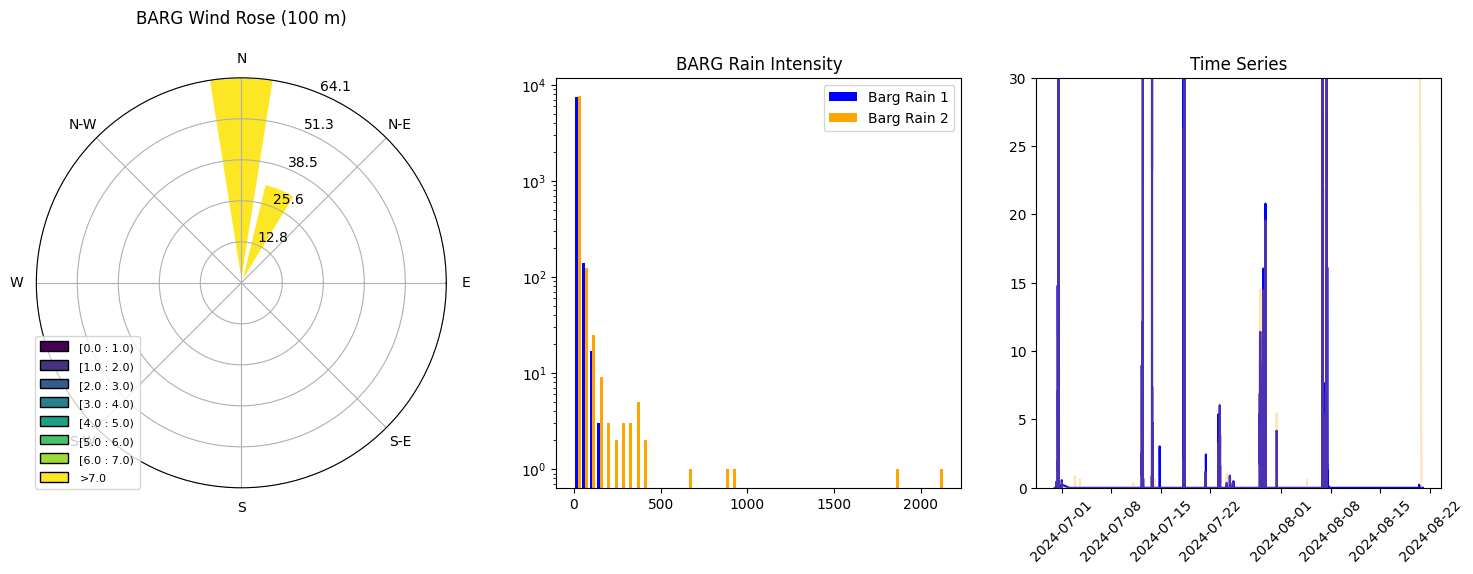

In [26]:
fig = plt.figure(figsize=(15, 5))

# Windrose subplot (left) — WindroseAxes requires manual rect positioning
ax1 = WindroseAxes(fig, [0.03, 0.1, 0.28, 0.82])
fig.add_axes(ax1)
ws = datasets['Barg Winds']['wind_direction'].sel(height=100).values  # wind speeds
wd = datasets['Barg Winds']['wind_speed'].sel(height=100).values  # wind directions
ax1.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax1.set_legend()
ax1.set_title('BARG Wind Rose (100 m)', pad=20)

# Rain intensity histogram subplot (middle)
ax2 = fig.add_axes([0.38, 0.1, 0.27, 0.82])
data1 = datasets['Barg Rain 1']['rain_intensity'].where(datasets['Barg Rain 1']['rain_intensity'] > 0).values
data2 = datasets['Barg Rain 2']['rain_intensity'].where(datasets['Barg Rain 2']['rain_intensity'] > 0).values
datas = [data1, data2]
ax2.hist(datas, bins=50, label=['Barg Rain 1', 'Barg Rain 2'], color=['blue', 'orange'])
ax2.set_title('BARG Rain Intensity')
ax2.legend()
ax2.set_yscale('log')  # Set y-axis to logarithmic scale for better visibility of low-frequency bins

# Time series subplot (right)
ax3 = fig.add_axes([0.70, 0.1, 0.27, 0.82])
ax3.plot(datasets['Barg Rain 1']['time'],datasets['Barg Rain 1']['rain_intensity'], color='blue')
ax3.plot(datasets['Barg Rain 2']['time'],datasets['Barg Rain 2']['rain_intensity'], color='orange',alpha=0.3)
ax3.set_title('Time Series')
ax3.set_ylim([0, 30])
plt.xticks(rotation=45)

plt.show()


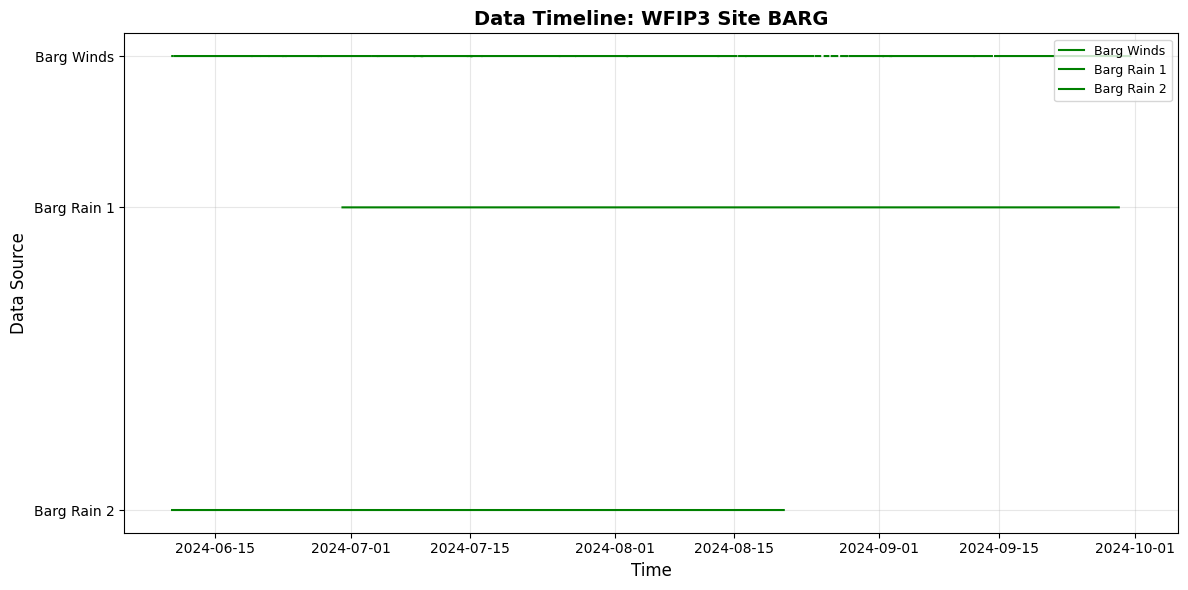

In [13]:
# Efficient refactored plotting using the datasets_config
fig, ax = plt.subplots(figsize=(12, 6))

# Plot all datasets using loop
for label, pattern, var, height, y_offset, color in datasets_config:
    if label not in datasets:
        print(f"Skipping {label}: not loaded")
        continue
    
    ds = datasets[label]
    try:
        if var not in ds.data_vars:
            print(f"  Skipping {var}: not in {label}")
            continue
        
        # Extract variable; select height if specified
        data = ds[var]
        if height is not None and 'height' in data.dims:
            data = data.sel(height=height, method='nearest')
        
        # Plot: y_offset values only mark timeline, time values show when data exists
        valid = np.isfinite(data.values)
        y = np.full(ds.time.size, np.nan, dtype=float)
        y[valid] = y_offset
        ax.plot(ds.time.values, y, label=label, color=color, linewidth=1.5)
        # ax.plot(ds.time, xr.full_like(ds.time, y_offset), label=label, color=color, linewidth=1.5)
    except Exception as e:
        print(f"  Error plotting {label}: {e}")

# Set labels and formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Data Source', fontsize=12)
positions = [row[4] for row in datasets_config]
labels_list = [row[0] for row in datasets_config]
ax.set_yticks(positions, labels_list, fontsize=10)
ax.set_title('Data Timeline: WFIP3 Site BARG', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

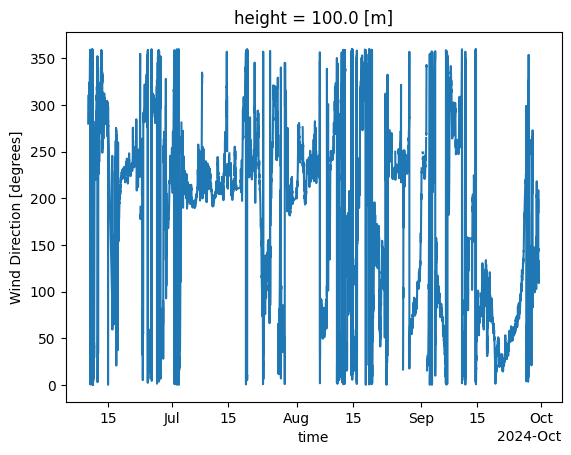

In [14]:
datasets['Barg Winds']['wind_direction'].sel(height=100).plot()

In [27]:
# Make sure eveything has same time coordinate
datasets['Barg Winds'] = datasets['Barg Winds'].reindex(time=datasets["Barg Rain 1"]["time"], method="ffill")
datasets['Barg Rain 2'] = datasets['Barg Rain 2'].reindex(time=datasets["Barg Rain 1"]["time"], method="ffill")

In [ ]:
WD = datasets['Barg Winds']['wind_direction'].sel(height=100, method = 'nearest')

ds1 = datasets["Barg Rain 1"]   # Dataset
ds2 = datasets["Barg Rain 2"]   # Dataset

# Boolean masks (True where condition met)
mask_ns = ((WD > 315) | (WD < 45) | ((WD > 135) & (WD < 225)))
mask_ew = (((WD > 45) & (WD < 135)) | ((WD > 225) & (WD < 315)))

new_ds = xr.where(mask_ns, ds1, xr.where(mask_ew, ds2, np.nan))

In [35]:

# Save daily files for new_ds only
import os
from datetime import datetime, timedelta

output_dir = '/qfs/people/gold396/ORACLE/wfip3/BARG'
os.makedirs(output_dir, exist_ok=True)

# Get sorted unique dates from new_ds
dates = sorted(set(pd.to_datetime(new_ds.time.values).normalize()))

for date in dates:
    date_str = pd.Timestamp(date).strftime('%Y%m%d')
    
    # Extract all data for this day from new_ds
    day_ds = new_ds.sel(time=slice(date, date + timedelta(days=1) - timedelta(seconds=1)))
    
    # Compute to materialize Dask arrays before saving
    day_ds = day_ds.compute()
    
    # Save to daily file
    output_file = os.path.join(output_dir, f"barg_merged_{date_str}.nc")
    day_ds.to_netcdf(output_file)
    print(f"✓ Saved {date_str}: {output_file}")

print(f"\nTotal daily files saved: {len(dates)}")


KeyboardInterrupt: 

In [30]:
new_ds.to_netcdf('/qfs/people/gold396/ORACLE/wfip3/barg_merged_rain.nc')

KeyboardInterrupt: 

### Now we can do barge statistics

In [49]:
arr = new_ds["weather_code_nws"].values.ravel().astype(str)

unique_strings, counts = np.unique(arr, return_counts=True)

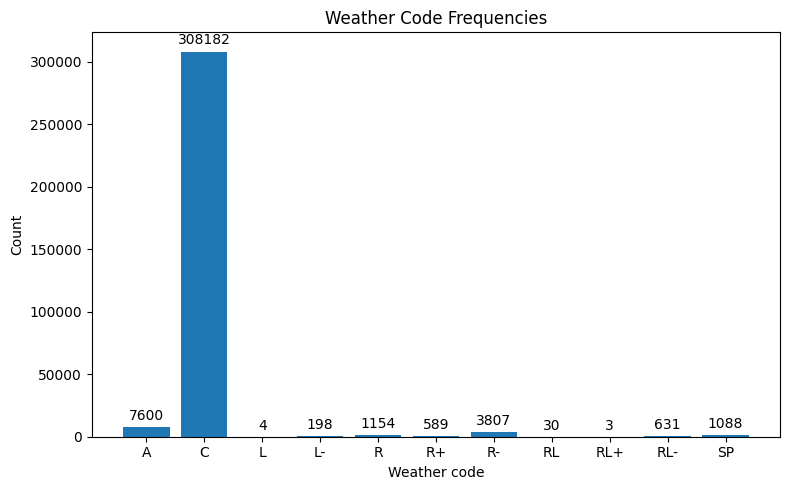

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(unique_strings[:-1], counts[:-1])
ax.bar_label(bars, labels=[str(x) for x in counts[:-1]], padding=3)
 
ax.set_xlabel("Weather code")
ax.set_ylabel("Count")
ax.set_title("Weather Code Frequencies")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

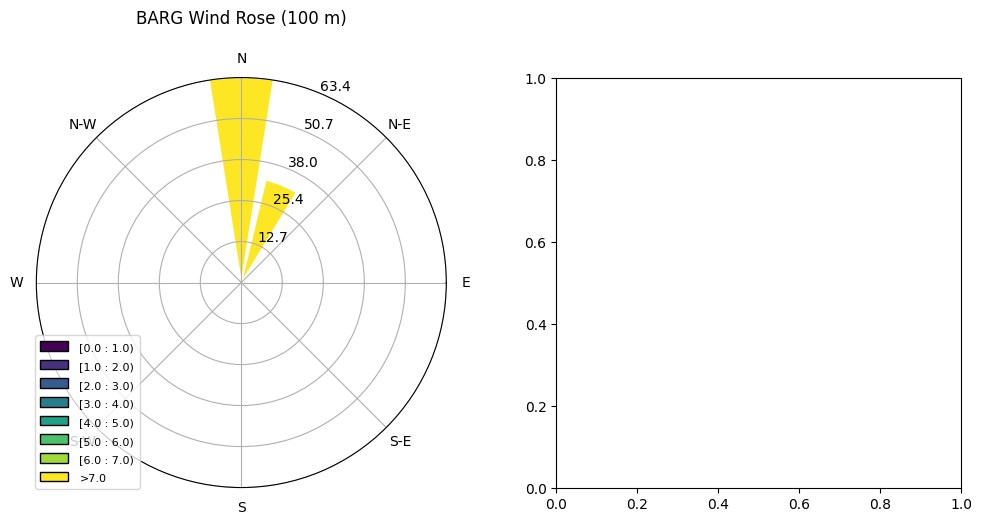

In [57]:
fig = plt.figure(figsize=(15, 5))

# Windrose subplot (left) — WindroseAxes requires manual rect positioning
ax1 = WindroseAxes(fig, [0.03, 0.1, 0.28, 0.82])
fig.add_axes(ax1)
ws = datasets['Barg Winds']['wind_direction'].sel(height=100).values  # wind speeds
wd = datasets['Barg Winds']['wind_speed'].sel(height=100).values  # wind directions
ax1.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax1.set_legend()
ax1.set_title('BARG Wind Rose (100 m)', pad=20)

# Rain intensity histogram subplot (middle)
ax2 = fig.add_axes([0.38, 0.1, 0.27, 0.82])
data1 = new_ds['rain_intensity'].where(new_ds['rain_intensity'] > 0).values
datas = [data1]
ax2.hist(datas, bins=50, label=['Merged Barge Data'], color=['green'])
ax2.set_title('BARG Rain Intensity')
ax2.legend()
ax2.set_yscale('log')  # Set y-axis to logarithmic scale for better visibility of low-frequency bins

# Time series subplot (right)
ax3 = fig.add_axes([0.70, 0.1, 0.27, 0.82])
ax3.plot(new_ds['time'], new_ds['rain_intensity'], color='green')
ax3.set_title('Time Series')
ax3.set_ylim([0, 30])
plt.xticks(rotation=45)

plt.show()


In [61]:
new_ds = new_ds.drop_vars("height")

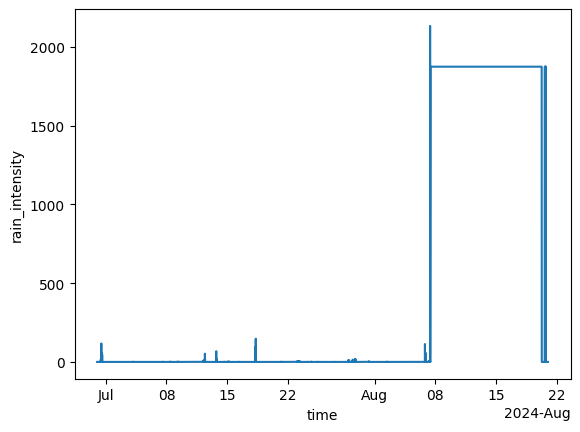

In [63]:
new_ds.rain_intensity.plot()

In [58]:
new_ds

<xarray.Dataset> Size: 113MB
Dimensions:                      (time: 336905)
Coordinates:
    height                       float64 8B 100.0
  * time                         (time) datetime64[ns] 3MB 2024-06-30 ... 202...
Data variables: (12/41)
    rain_intensity               (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    rain_accumulated             (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4680      (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4677      (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_synop_4678      (time) object 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    weather_code_nws             (time) object 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                           ...
    qc_sensor_voltage            (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_sensor_status             (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_right_sensor_temperature  (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_left_sensor_temperature   (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_kinetic_energy            (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>
    qc_snow_intensity            (time) float64 3MB dask.array<chunksize=(1,), meta=np.ndarray>

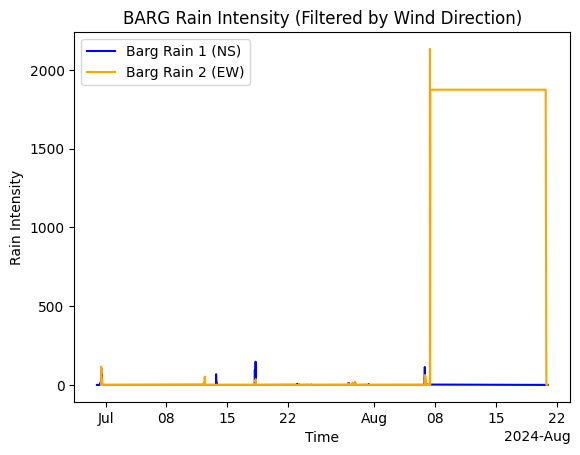

In [65]:
WD = datasets['Barg Winds']['wind_direction'].sel(height=100, method = 'nearest').compute()

ds1 = datasets["Barg Rain 1"]   # Dataset
ds2 = datasets["Barg Rain 2"]   # Dataset

# Boolean masks (True where condition met)
mask_ns = ((WD > 315) | (WD < 45) | ((WD > 135) & (WD < 225)))
mask_ew = (((WD > 45) & (WD < 135)) | ((WD > 225) & (WD < 315)))

# new_ds = xr.where(mask_ns, ds1, xr.where(mask_ew, ds2, np.nan))

datasets["Barg Rain 1"]["rain_intensity"][mask_ns].plot(label="Barg Rain 1 (NS)", color="blue")
datasets["Barg Rain 2"]["rain_intensity"][mask_ew].plot(label="Barg Rain 2 (EW)", color="orange")
plt.title("BARG Rain Intensity (Filtered by Wind Direction)")
plt.xlabel("Time")
plt.ylabel("Rain Intensity")
plt.legend()
plt.show()  

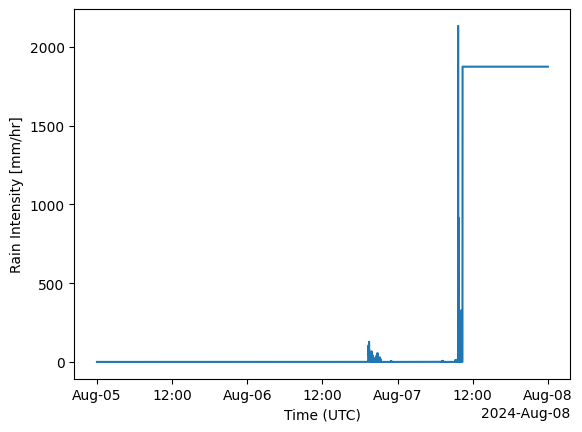

In [66]:
# Select the date range from August 5th to August 10th, 2024, and plot it
datasets["Barg Rain 2"]["rain_intensity"].sel(time=slice("2024-08-05", "2024-08-10")).plot()


In [ ]:
datasets["Barg Winds"]["wind_direction"][mask_ns].plot(label="Barg Winds (NS)", color="blue")
datasets["Barg Winds"]["wind_direction"][mask_ew].plot(label="Barg Winds (EW)", color="orange")
plt.title("BARG Wind Direction (Filtered by Wind Direction)")
plt.xlabel("Time")
plt.ylabel("Wind Direction")
plt.legend()
plt.show() 

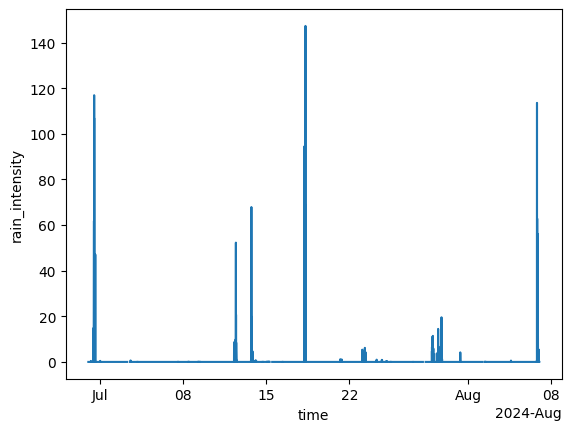

In [68]:
# Filter data up to (and including) August 6th or 7th, 2024
new_ds_filtered = new_ds.sel(time=slice(None, "2024-08-06"))
new_ds_filtered.rain_intensity.plot()


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_yscale'

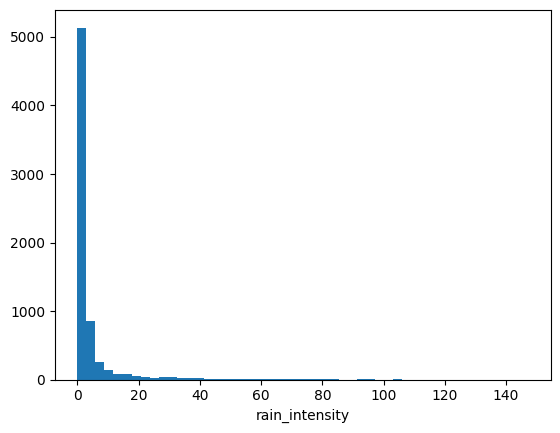

In [71]:
new_ds_filtered['rain_intensity'].where(new_ds_filtered['rain_intensity'] > 0).plot.hist(bins=50)
plt.set_yscale('log')